In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "6"

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from diffusers import StableDiffusionXLPipeline
from transformers import AutoTokenizer, CLIPTextModel, CLIPTextModelWithProjection

from dti.utils import load_embedding, get_close_words
from dti.text_encoder.clip import TextModel, TextModelWithProjection

MODEL = "stabilityai/stable-diffusion-xl-base-1.0"

torch.set_grad_enabled(False)

/local2/kunkim/dti/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
pipeline = StableDiffusionXLPipeline.from_pretrained(MODEL).to(
    "cuda", dtype=torch.float16
)
learned_embeds = [
    "../output/ti-sdxlbase-baseline/backpack/learned_embeds.safetensors",
    "../output/ti-sdxlbase-baseline/backpack/learned_embeds_2.safetensors",
    # "../output/d2ti-sdxlbase-db-noreg/backpack_dog/learned_embeds.safetensors",
    # "../output/d2ti-sdxlbase-db-noreg/backpack_dog/learned_embeds_2.safetensors",
]

identifier = ""
embeddings = []
for i, path in enumerate(learned_embeds):
    if i == 0:
        tokenizer = pipeline.tokenizer
        text_encoder = pipeline.text_encoder
    elif i == 1:
        tokenizer = pipeline.tokenizer_2
        text_encoder = pipeline.text_encoder_2
    identifier = load_embedding(
        tokenizer=tokenizer,
        text_encoder=text_encoder,
        state_dict=path,
    )
    embedding = text_encoder.get_input_embeddings().weight[-1].detach().clone()
    embeddings.append(embedding)
print(identifier)

Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00,  8.48it/s]
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


['<backpack>']


  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:09<00:00,  5.51it/s]


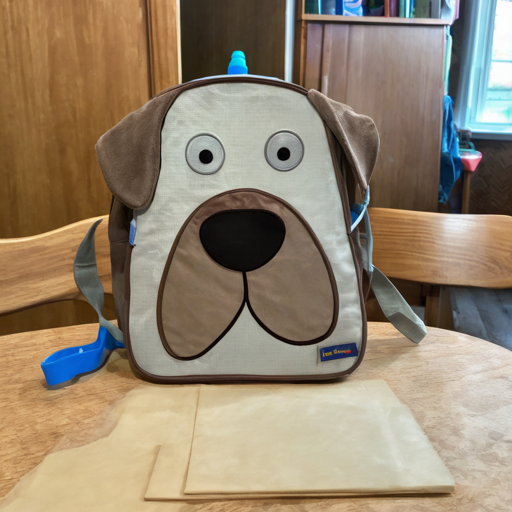

In [20]:
generator = torch.Generator(device="cuda").manual_seed(1)
images = pipeline(
    f"a {identifier} on the table",
    generator=generator,
).images
images[0].resize((512, 512))

tensor(1.8350, device='cuda:0', dtype=torch.float16)
tensor(2.6699, device='cuda:0', dtype=torch.float16)


  4%|▍         | 2/50 [00:00<00:06,  7.47it/s]

100%|██████████| 50/50 [00:09<00:00,  5.49it/s]


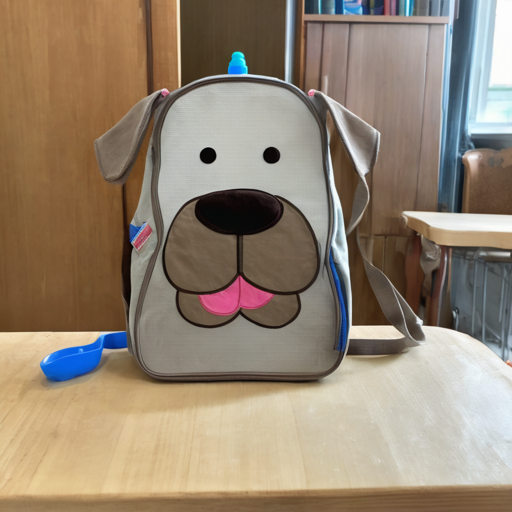

In [31]:
for emb in embeddings:
    print(emb.norm())
pipeline.text_encoder.get_input_embeddings().weight[49408] = (
    0.65 * embeddings[0] / embeddings[0].norm()
)
pipeline.text_encoder_2.get_input_embeddings().weight[49408] = (
    0.80 * embeddings[1] / embeddings[1].norm()
)

generator = torch.Generator(device="cuda").manual_seed(1)
images = pipeline(
    f"a {identifier} on the table",
    generator=generator,
).images
images[0].resize((512, 512))

In [ ]:
all_embeddings = (
    pipeline.text_encoder_2.get_input_embeddings().weight.detach().clone().float()
)
# cos_sim = F.cosine_similarity(all_embeddings, embeddings[-1].unsqueeze(0), dim=-1)
cos_sim = F.cosine_similarity(all_embeddings, all_embeddings[1952].unsqueeze(0), dim=-1)

print(cos_sim.shape)
values, topk = cos_sim.topk(10)
print(values, topk)
print(topk)
for v, i in zip(values, topk):
    print(f"{tokenizer.decode(i.item())}, {v.item():.3f}")

torch.Size([49409])
tensor([1.0000, 0.3719, 0.2873, 0.2768, 0.2207, 0.1963, 0.1680, 0.1653, 0.1525,
        0.1519], device='cuda:0') tensor([ 1951,  6351, 15486, 17243,  4314, 39029, 11290, 19602, 40672,   637],
       device='cuda:0')
tensor([ 1951,  6351, 15486, 17243,  4314, 39029, 11290, 19602, 40672,   637],
       device='cuda:0')
phone, 1.000
phones, 0.372
phone, 0.287
telephone, 0.277
iphone, 0.221
cellphone, 0.196
smartphone, 0.168
phon, 0.165
fone, 0.153
one, 0.152


photo of a backpack
tensor([[49406,  1125,   539,   320, 14894, 49407,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0]])


CLIPModel is using CLIPSdpaAttention, but `torch.nn.functional.scaled_dot_product_attention` does not support `output_attentions=True`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


0 -9.5367386e-07
1 0.5408458
2 0.8888656
3 1.2619662
4 1.0182027
5 0.8265108
6 1.6748649
7 1.7469206
8 1.9297286
9 2.0900877
10 2.1893458
11 2.261633
12 2.3353226
13 2.4026194
14 2.461484


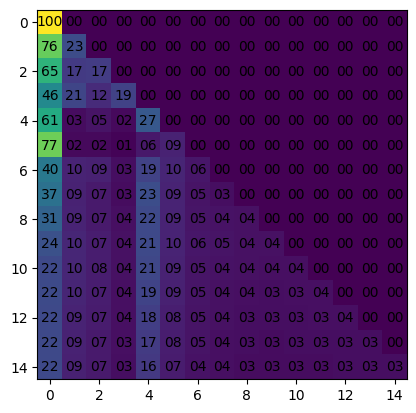

In [3]:
def get_attn(concept, layer=-1):
    tokenizer = AutoTokenizer.from_pretrained(MODEL, subfolder="tokenizer")
    text_encoder = CLIPTextModel.from_pretrained(MODEL, subfolder="text_encoder")
    text_encoder.to("cuda")

    tokenizer_2 = AutoTokenizer.from_pretrained(MODEL, subfolder="tokenizer_2")
    text_encoder_2 = CLIPTextModelWithProjection.from_pretrained(
        MODEL, subfolder="text_encoder_2"
    )
    text_encoder_2.to("cuda")

    # prompt = f"In the ocean, <{concept}> is swimming."
    # prompt = f"In the ocean, {concept} is swimming."
    prompt = f"photo of a {concept}"
    print(prompt)

    input_ids = tokenizer_2(prompt, return_tensors="pt", padding="max_length").input_ids
    print(input_ids)

    output = text_encoder_2(
        input_ids.to("cuda"),
        output_attentions=True,
        return_dict=True,
    )  # "text_embeds", "last_hidden_states", "attentions",

    del text_encoder
    del text_encoder_2
    torch.cuda.empty_cache()
    return output["attentions"][layer].cpu().detach().numpy()


attn = get_attn("backpack", layer=-1)[0].mean(axis=0)[:15, :15]

plt.imshow(attn, vmin=0, vmax=1)
# write attention values on the plot
for (i, j), label in np.ndenumerate(attn):
    plt.text(j, i, f"{int(label * 100):02d}", ha="center", va="center", color="black")

for row in range(attn.shape[0]):
    valid = attn[row, : row + 1]
    entropy = -np.sum(valid * np.log(valid + 1e-6))
    print(row, entropy)
plt.show()

photo of a <backpack>
tensor([[49406,  1125,   539,   320, 49408, 49407,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0]])
0 -9.5367386e-07
1 0.35705063
2 0.8483348
3 0.9568766
4 0.36894828
5 1.2526168
6 1.3907113
7 1.5050381
8 1.5879433
9 1.6501392
10 1.7147228
11 1.7673128
12 1.8000606
13 1.8200679
14 1.8343407


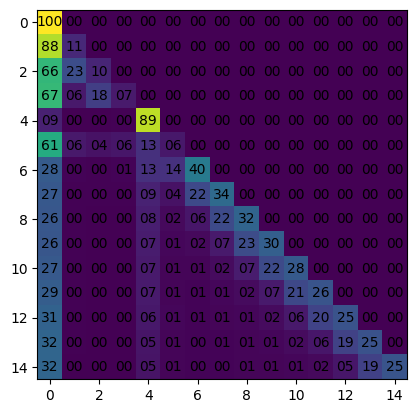

In [11]:
def get_attn_ti(concept, layer=-1):
    tokenizer = AutoTokenizer.from_pretrained(MODEL, subfolder="tokenizer")
    text_encoder = CLIPTextModel.from_pretrained(MODEL, subfolder="text_encoder")
    text_encoder.to("cuda")

    tokenizer_2 = AutoTokenizer.from_pretrained(MODEL, subfolder="tokenizer_2")
    text_encoder_2 = CLIPTextModelWithProjection.from_pretrained(
        MODEL, subfolder="text_encoder_2"
    )
    text_encoder_2.to("cuda")

    identifier = load_embedding(
        tokenizer=tokenizer,
        text_encoder=text_encoder,
        state_dict=f"../output/ti-sdxlbase-baseline/{concept}/learned_embeds.safetensors",
    )

    identifier = load_embedding(
        tokenizer=tokenizer_2,
        text_encoder=text_encoder_2,
        state_dict=f"../output/ti-sdxlbase-baseline/{concept}/learned_embeds_2.safetensors",
    )

    # prompt = f"In the ocean, <{concept}> is swimming."
    # prompt = f"In the ocean, {concept} is swimming."
    prompt = f"photo of a {identifier[0]}"
    # prompt = f"photo of a {concept}"
    print(prompt)

    input_ids = tokenizer_2(prompt, return_tensors="pt", padding="max_length").input_ids
    print(input_ids)

    output = text_encoder_2(
        input_ids.to("cuda"),
        output_attentions=True,
        return_dict=True,
    )  # "text_embeds", "last_hidden_states", "attentions",

    del text_encoder
    del text_encoder_2
    torch.cuda.empty_cache()
    return output["attentions"][layer].cpu().detach().numpy()


attn = get_attn_ti("backpack", layer=0)[0].mean(axis=0)[:15, :15]

plt.imshow(attn, vmin=0, vmax=1)
# write attention values on the plot
for (i, j), label in np.ndenumerate(attn):
    plt.text(j, i, f"{int(label * 100):02d}", ha="center", va="center", color="black")

for row in range(attn.shape[0]):
    valid = attn[row, : row + 1]
    entropy = -np.sum(valid * np.log(valid + 1e-6))
    print(row, entropy)
# 0 -9.5367386e-07
# 1 0.604185
# 2 0.6545978
# 3 1.0813066
# 4 1.3316563
# 5 1.3785033
# 6 1.7939984
# 7 1.5548866
# 8 1.7921485
# 9 1.9995079

plt.show()

photo of a <backpack>
tensor([[49406,  1125,   539,   320, 49408, 49407,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0]])
0 -9.5367386e-07
1 0.35705063
2 0.8483348
3 0.9568766
4 0.53208184
5 1.2680207
6 1.3913532
7 1.4948577
8 1.5687021
9 1.6356957
10 1.7055454
11 1.7612967
12 1.7941732
13 1.8161379
14 1.8361957


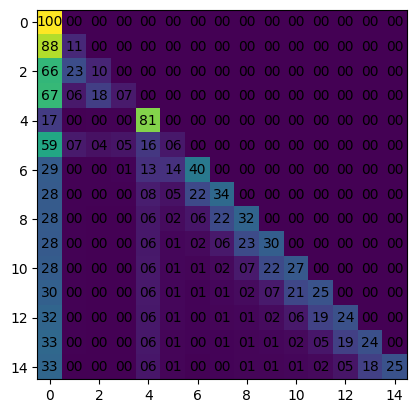

In [10]:
def get_attn_bti(concept, layer=-1):
    tokenizer = AutoTokenizer.from_pretrained(MODEL, subfolder="tokenizer")
    text_encoder = CLIPTextModel.from_pretrained(MODEL, subfolder="text_encoder")
    text_encoder.to("cuda")

    tokenizer_2 = AutoTokenizer.from_pretrained(MODEL, subfolder="tokenizer_2")
    text_encoder_2 = CLIPTextModelWithProjection.from_pretrained(
        MODEL, subfolder="text_encoder_2"
    )
    text_encoder_2.to("cuda")

    identifier = load_embedding(
        tokenizer=tokenizer,
        text_encoder=text_encoder,
        state_dict=f"../output/dtir-sdxlbase-512-k0.0/{concept}/learned_embeds.safetensors",
    )

    identifier = load_embedding(
        tokenizer=tokenizer_2,
        text_encoder=text_encoder_2,
        state_dict=f"../output/dtir-sdxlbase-512-k0.0/{concept}/learned_embeds_2.safetensors",
    )

    # prompt = f"In the ocean, <{concept}> is swimming."
    # prompt = f"In the ocean, {concept} is swimming."
    prompt = f"photo of a {identifier[0]}"
    print(prompt)

    input_ids = tokenizer_2(prompt, return_tensors="pt", padding="max_length").input_ids
    print(input_ids)

    output = text_encoder_2(
        input_ids.to("cuda"),
        output_attentions=True,
        return_dict=True,
    )  # "text_embeds", "last_hidden_states", "attentions",

    del text_encoder
    del text_encoder_2
    torch.cuda.empty_cache()
    return output["attentions"][layer].cpu().detach().numpy()


attn = get_attn_bti("backpack", layer=0)[0].mean(axis=0)[:15, :15]

plt.imshow(attn, vmin=0, vmax=1)
# write attention values on the plot
for (i, j), label in np.ndenumerate(attn):
    plt.text(j, i, f"{int(label * 100):02d}", ha="center", va="center", color="black")

for row in range(attn.shape[0]):
    valid = attn[row, : row + 1]
    entropy = -np.sum(valid * np.log(valid + 1e-6))
    print(row, entropy)
# 0 -9.5367386e-07
# 1 0.604185
# 2 0.6545978
# 3 1.0813066
# 4 1.3316563
# 5 1.3785033
# 6 1.7939984
# 7 1.5548866
# 8 1.7921485
# 9 1.9995079

plt.show()

Some weights of BtiTextModel were not initialized from the model checkpoint at stabilityai/stable-diffusion-xl-base-1.0 and are newly initialized: ['text_model.embeddings.token_scale.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of BtiTextModelWithProjection were not initialized from the model checkpoint at stabilityai/stable-diffusion-xl-base-1.0 and are newly initialized: ['text_model.embeddings.token_scale.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


AttributeError: 'str' object has no attribute 'keys'

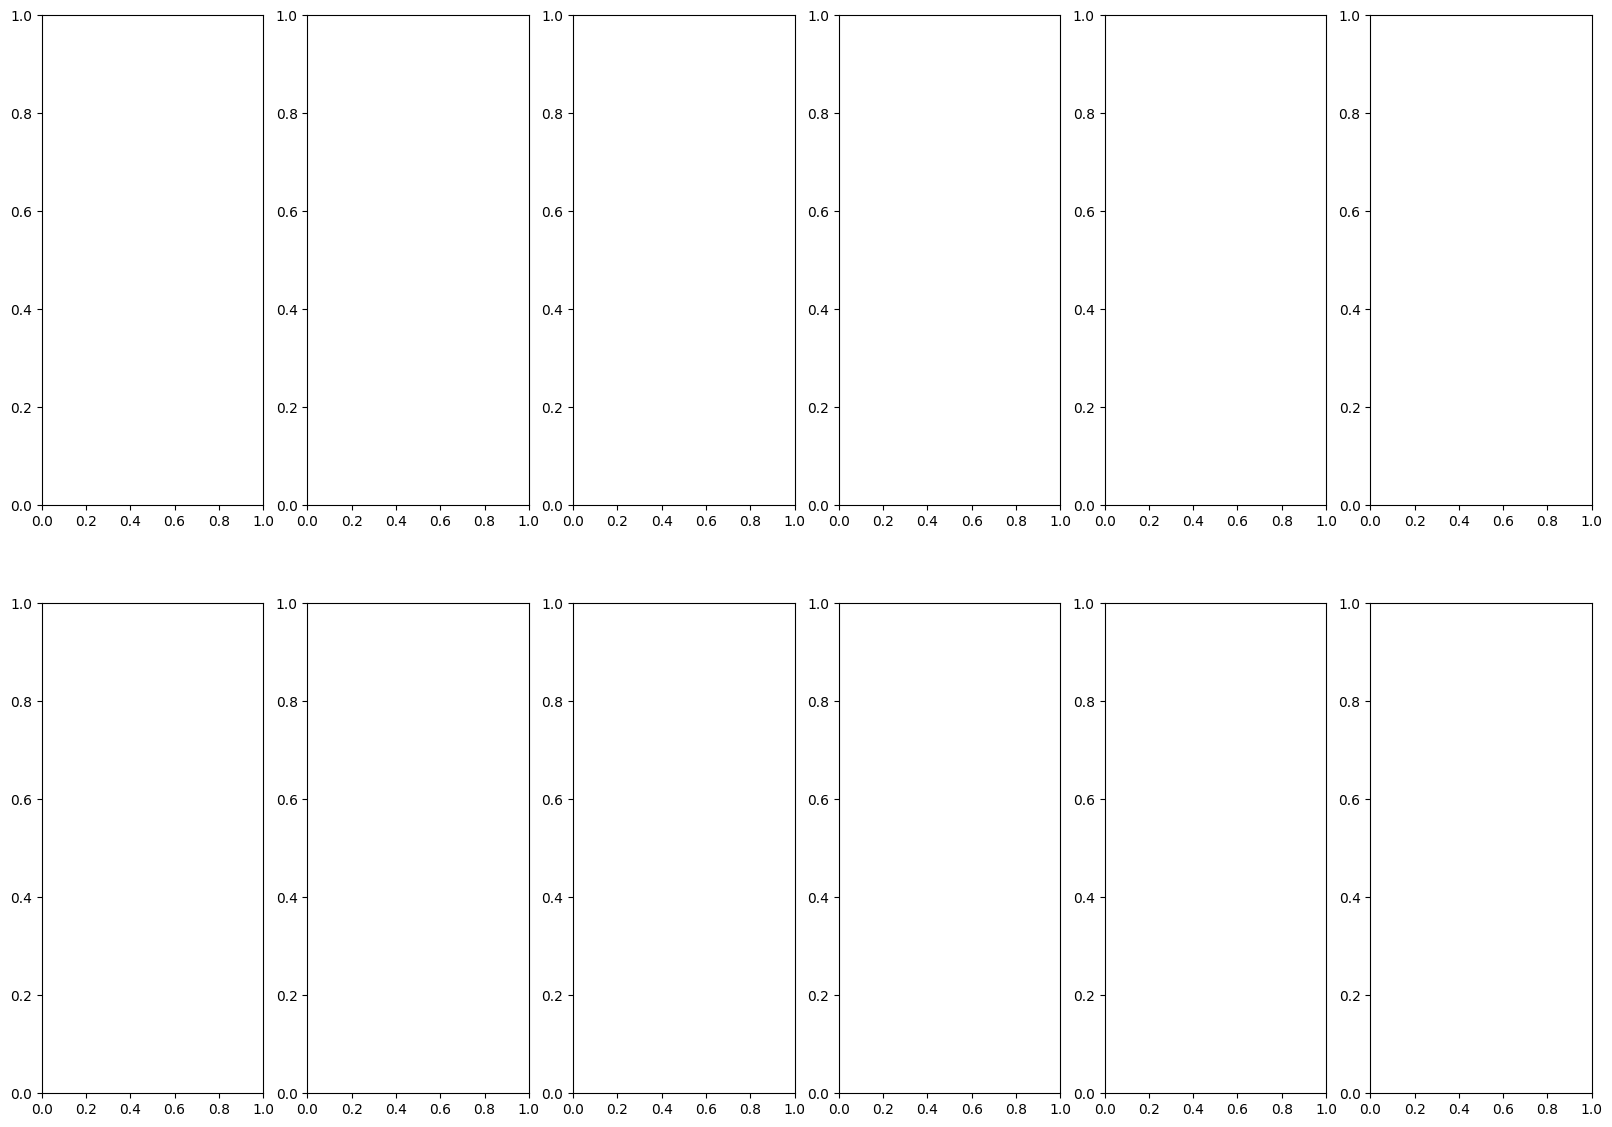

In [6]:
concepts = [
    "backpack",
    "backpack_dog",
    "berry_bowl",
    "can",
    "candle",
    "clock",
    "colorful_sneaker",
    "duck_toy",
    "fancy_boot",
    "monster_toy",
    "pink_sunglasses",
    "poop_emoji",
    "rc_car",
    "cat",
    "cat2",
    "dog",
    "dog2",
    "dog3",
    "dog5",
    "dog6",
    "dog7",
    "dog8",
]

concepts = [
    "can",
    "duck_toy",
    "poop_emoji",
    "backpack_dog",
    "cat",
    "cat2",
    "dog2",
    "dog3",
    "dog5",
    "dog6",
    "dog7",
    "dog8",
]

fig, axs = plt.subplots(2, len(concepts) // 2, figsize=(20, 14))
idx = 0
for row in range(2):
    for col in range(len(concepts) // 2):
        concept = concepts[idx]
        attn = get_attn_bti(concept, layer=-1)[0].mean(axis=0)[:10, :10]

        axs[row, col].imshow(attn, vmin=0, vmax=1)
        axs[row, col].set_title(concept)
        # write attention values on the plot
        for (i, j), label in np.ndenumerate(attn):
            axs[row, col].text(
                j, i, f"{label:.2f}", ha="center", va="center", color="black"
            )
        idx += 1
plt.show()

CLIPTokenizer(name_or_path='/local/kunkim/hf_home/hub/models--stabilityai--stable-diffusion-xl-base-1.0/snapshots/462165984030d82259a11f4367a4eed129e94a7b/tokenizer', vocab_size=49408, model_max_length=77, is_fast=False, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<|startoftext|>', 'eos_token': '<|endoftext|>', 'unk_token': '<|endoftext|>', 'pad_token': '<|endoftext|>'}, clean_up_tokenization_spaces=True, added_tokens_decoder={
	49406: AddedToken("<|startoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	49407: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
}
)
[0.4192188  0.4270667  0.39022934 ... 0.4036076  0.66141635 1.0966524 ]
(49201,)
0.3870101 0.017747095


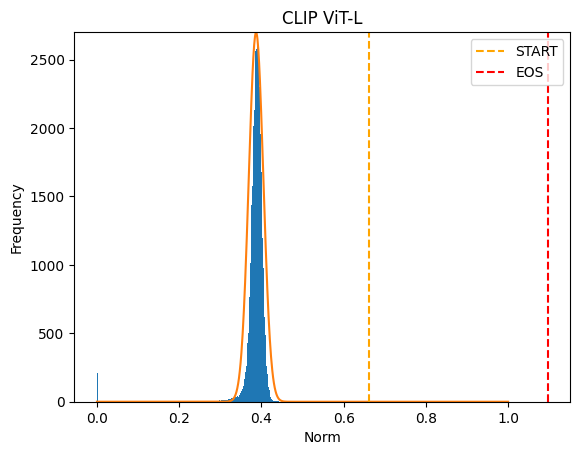

In [3]:
print(pipeline.tokenizer)
embedding = pipeline.text_encoder.get_input_embeddings().weight.detach().clone().float()
norms = embedding.norm(dim=-1).cpu().numpy()
print(norms)

valid_norms = norms[norms > 0.0]
print(valid_norms.shape)
mean = valid_norms.mean()
std = valid_norms.std()
print(mean, std)
x = np.linspace(0, 1, 1000)
y = np.exp(-0.5 * ((x - mean) / std) ** 2) / (std * np.sqrt(2 * np.pi))

plt.hist(norms[:-2], bins=300)
plt.plot(x, y * 120)
plt.vlines(norms[49406], 0, 2700, linestyle="--", color="orange", label="START")
plt.vlines(norms[49407], 0, 2700, linestyle="--", color="red", label="EOS")
plt.ylim(0, 2700)
plt.xlabel("Norm")
plt.ylabel("Frequency")
plt.title("CLIP ViT-L")
plt.legend()

CLIPTokenizer(name_or_path='/local/kunkim/hf_home/hub/models--stabilityai--stable-diffusion-xl-base-1.0/snapshots/462165984030d82259a11f4367a4eed129e94a7b/tokenizer_2', vocab_size=49408, model_max_length=77, is_fast=False, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<|startoftext|>', 'eos_token': '<|endoftext|>', 'unk_token': '<|endoftext|>', 'pad_token': '!'}, clean_up_tokenization_spaces=True, added_tokens_decoder={
	0: AddedToken("!", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	49406: AddedToken("<|startoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	49407: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
}
)
[0.50809634 0.5988674  0.4950142  ... 0.48704264 0.98246086 0.6894792 ]
(49184,)
0.4515043 0.110259764


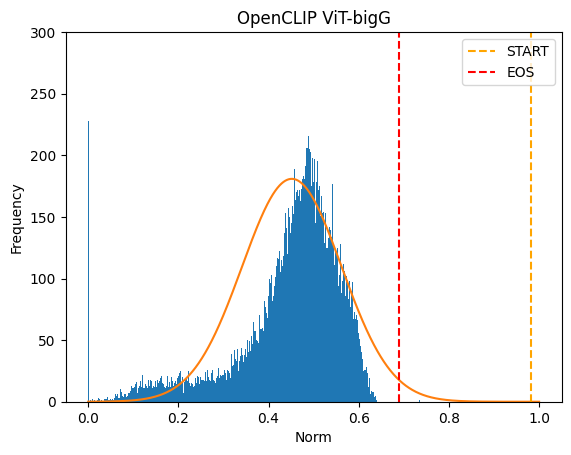

In [4]:
print(pipeline.tokenizer_2)
embedding = (
    pipeline.text_encoder_2.get_input_embeddings().weight.detach().clone().float()
)
norms = embedding.norm(dim=-1).cpu().numpy()
print(norms)


valid_norms = norms[norms > 0.0]
print(valid_norms.shape)
mean = valid_norms.mean()
std = valid_norms.std()
print(mean, std)
x = np.linspace(0, 1, 1000)
y = np.exp(-0.5 * ((x - mean) / std) ** 2) / (std * np.sqrt(2 * np.pi))

plt.hist(norms[:-2], bins=1000)
plt.plot(x, y * 50)
plt.vlines(norms[49406], 0, 300, linestyle="--", color="orange", label="START")
plt.vlines(norms[49407], 0, 300, linestyle="--", color="red", label="EOS")
plt.ylim(0, 300)
plt.xlabel("Norm")
plt.ylabel("Frequency")
plt.title("OpenCLIP ViT-bigG")
plt.legend()

In [45]:
from safetensors.torch import load_file

embedding = (
    pipeline.text_encoder_2.get_input_embeddings().weight.detach().clone().float()
)
# v = embedding[49408].reshape(1, -1)

instance = "backpack_dog"
ckpt = load_file(
    f"../output/dtir-sdxlbase-pad/{instance}/learned_embeds_2-steps-1000.safetensors"
)
# ckpt = load_file(f"../output/dtir-sdxlbase-test/{instance}/learned_embeds_2-steps-800.safetensors")
print(ckpt.keys())
v = ckpt[f"<{instance}>"].cuda()
v = ckpt[f"<{instance}>"][0].cuda()
print(v.norm())

idx = pipeline.tokenizer_2.encode("backpacks", add_special_tokens=False)[0]
# v = embedding[idx].reshape(1, -1)
print(idx)

cos_sim_matrix = F.cosine_similarity(v, embedding, dim=-1)
print(cos_sim_matrix[idx])
print()
values, topk = cos_sim_matrix.topk(100)
for v, i in zip(values, topk):
    print(f"{pipeline.tokenizer_2.decode(i.item())}, {v.item():.3f}")

dict_keys(['<backpack_dog>'])
tensor(0.9844, device='cuda:0')
37063
tensor(0.1501, device='cuda:0')

backpack, 0.286
backpacks, 0.150
joyce, 0.145
undere, 0.140
puppylove, 0.139
maisie, 0.133
georgina, 0.132
unhcr, 0.131
swel, 0.131
cleve, 0.130
bayer, 0.130
litur, 0.129
delavin, 0.129
socute, 0.129
mop, 0.126
grinch, 0.126
ransomware, 0.125
capecod, 0.125
featherweight, 0.125
scour, 0.125
therapeu, 0.125
dogsoftwitter, 0.125
transformation, 0.124
freck, 0.124
tolerate, 0.124
graces, 0.123
pietro, 0.122
nighter, 0.122
khal, 0.122
unaware, 0.120
anab, 0.120
scarecrow, 0.119
punisher, 0.119
bluewave, 0.118
happ, 0.118
gillespie, 0.118
behavioural, 0.118
ghead, 0.117
monaghan, 0.117
dubu, 0.116
alfie, 0.116
kumar, 0.116
omer, 0.116
riya, 0.115
robyn, 0.115
vodafone, 0.115
duff, 0.115
morph, 0.115
johannes, 0.114
😑, 0.114
reza, 0.114
highlighter, 0.114
bluebird, 0.113
mersal, 0.113
ragon, 0.113
ableton, 0.113
palae, 0.113
signingday, 0.113
dune, 0.112
matter, 0.111
pto, 0.111
nasal, 0.111


In [1]:
from dtir.text_encoder.clip import TextModelWithProjection


encoder = TextModelWithProjection.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    subfolder="text_encoder_2",
)
print(encoder.get_max_scale())

/local2/kunkim/dtir/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Some weights of TextModelWithProjection were not initialized from the model checkpoint at stabilityai/stable-diffusion-xl-base-1.0 and are newly initialized: ['text_model.embeddings.token_scale.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


0.7348729968070984


In [ ]:
import torch

scale = torch.norm(
    encoder.text_model.embeddings.token_embedding.weight,
    dim=-1,
    keepdim=True,
).view(-1)
topk, idx = torch.topk(scale, 10)
print(topk, idx)

tensor([0.9825, 0.7349, 0.6895, 0.6496, 0.6424, 0.6406, 0.6402, 0.6402, 0.6394,
        0.6390], grad_fn=<TopkBackward0>) tensor([49406,  8285, 49407, 36950,  8658, 25539,  3929,  1742,   318,   257])
